## Setting up our environment

### Install packages and configure clients

First things first, we need to install some packages:

1. [DocumentCloud Python SDK](https://documentcloud.readthedocs.io/en/latest) provides a convenient wrapper for the DocumentCloud API.
2. [MuckRock Requests Python SDK](https://python-muckrock.readthedocs.io/en/latest/) provides a convenient wrapper for the MuckRock API.
3. [Anthropic Python SDK](https://platform.claude.com/docs/en/api/sdks/python) provides a convenient wrapper for the Anthropic API to access Claude.
4. [python-dotenv](https://github.com/theskumar/python-dotenv) will help us load secrets saved in a `.env` file.
5. [pandas](https://pandas.pydata.org/) will help us work with data manipulation.

Install these with `uv sync` outside the notebook.

Then, we need to create clients for accessing DocumentCloud and Anthropic.

We can access public DocumentCloud projects without providing credentials, but we'll need to make sure we have `ANTHROPIC_API_KEY` set in our environment.

In [1]:
import os
import dotenv

dotenv.load_dotenv()

def create_documentcloud_client():
    from documentcloud import DocumentCloud
    client = None
    try:
        client = DocumentCloud()
        print("DocumentCloud client created successfully")
    except Exception as e:
        print("Error while creating DocumentCloud client: ", e)
    return client


def create_muckrock_client():
    from muckrock import MuckRock
    client = None
    try:
        client = MuckRock()
        print("MuckRock client created successfully")
    except Exception as e:
        print("Error while creating MuckRock client: ", e)
    return client


def create_anthropic_client():
    from anthropic import Anthropic
    client = None
    try:
        api_key = os.environ["ANTHROPIC_API_KEY"]
        if not api_key:
            raise ValueError("ANTHROPIC_API_KEY is not set")
        client = Anthropic(api_key=api_key)
        print("Anthropic client created successfully")
    except Exception as e:
        print("Error while creating Anthropic client: ", e)
    return client


documentcloud = create_documentcloud_client()
muckrock = create_muckrock_client()
anthropic = create_anthropic_client()

DocumentCloud client created successfully
MuckRock client created successfully
Anthropic client created successfully


### Helper functions

To make it easier to work with Claude and CSV data, we're going to define a few helper functions. Claude returns **all** its responses in Markdown, so having utilities to parse and format Markdown will be really helpful.

- `claude` will take a message and an optional system prompt and return a response
- `extract_csv_from_response` will parse CSV data out of Claude's response
- `extract_code_from_response` will parse Python code out of Claude's response
- `parallel_request` will execute a provided lambda function across iterable data
- `save_csv` will save provided data into a CSV file
- `load_csv` will load data from a provided CSV filename
- `load_csv_to_dataframe` will call `load_csv` and return its data in a pandas dataframe
- `format_md` will format Markdown outputs in this notebook

In [ ]:
import io
import pandas as pd

def claude(prompt, system="You are a helpful assistant for data journalism tasks."):
    try:
      print("Sending prompt to Claude...")
      message = anthropic.messages.create(
          model="claude-sonnet-4-6",
          max_tokens=12000,
          temperature=0,
          system=system,
          messages=[
              {"role": "user", "content": prompt}
          ]
      )
      return message.content[0].text
    except Exception as e:
      return f"An error occurred: {e}"


def extract_csv_from_response(raw_text):
    # Find the start and end of the CSV block if it's wrapped in backticks
    if '```csv' in raw_text:
        csv_content = raw_text.split('```csv')[1].split('```')[0].strip()
    elif '```' in raw_text:
        csv_content = raw_text.split('```')[1].split('```')[0].strip()
    else:
        csv_content = raw_text.strip()
    return csv_content


def extract_code_from_response(raw_text, language='python'):
    """Extract code from a Markdown-formatted response."""
    if f'```{language}' in raw_text:
        return raw_text.split(f'```{language}')[1].split('```')[0].strip()
    elif '```' in raw_text:
        return raw_text.split('```')[1].split('```')[0].strip()
    return raw_text.strip()


def parallel_request(lambdaFn, dataset):
    # Execute a lambda function against every element in a set
    # We use parallel processing to speed things up
    from concurrent.futures import ThreadPoolExecutor

    with ThreadPoolExecutor() as pool:
        result = list(pool.map(lambda doc: lambdaFn(doc), dataset))
    return result

def save_csv(csv_content, filename):
    os.makedirs('output', exist_ok=True)
    with open(f'output/{filename}', 'w') as f:
      f.write(csv_content)
    print(f'CSV content saved to output/{filename}')

def load_csv(filename):
    with open(f'output/{filename}', 'r') as f:
      csv_data = f.read()
    return csv_data

def load_csv_to_dataframe(filename):
    # Load into a pandas DataFrame to verify and display
    csv_data = load_csv(filename)
    df = pd.read_csv(io.StringIO(csv_data))
    display(df)
    return df

def format_md(text):
    from IPython.display import Markdown, display
    display(Markdown(text))

With our tools configured, let's start exploring some projects. 

# Trump Pardons

Our colleague Chris Amico used DocumentCloud's [Scraper Add-On][scraper] to automatically upload newly issued presidential pardons into a [project][trump-pardons]. Let's use Claude to explore this document set.

## Extract Data

When a document uploaded to DocumentCloud, check if it has text embedded in it. If it doesn't, we process it with the [`tesseract`][tesseract] OCR library, so its text is searchable.

In this project, the PDFs all come with embedded text. The text content is (mostly) clean, easy to work with, and accurate to the document's contents.

[tesseract]: https://tesseract-ocr.github.io/tessdoc/
[scraper]: https://www.documentcloud.org/add-ons/MuckRock/documentcloud-scraper-addon/
[trump-pardons]: https://www.documentcloud.org/projects/221636-trump-pardons/

In [39]:
# Fetch the project from documentcloud
trump_pardons = documentcloud.projects.get(221636)
display(f"Number of documents in the project: {len(trump_pardons.documents)}")

document_text = parallel_request(lambda doc: doc.full_text, trump_pardons.documents)
display(document_text)

'Number of documents in the project: 97'

['Executive Grant of Clemency \nDonald J. Trump \nPresident of the United States of America \nTo ALL TO WHOM THESE PRESENTS SHALL COME, GREETING: \nBE IT KNOWN, THAT THIS DAY, I, DONALD J. TRUMP, PRESIDENT \nOF THE UNITED STATES, PURSUANT TO MY POWERS UNDER \nARTICLE II, SECTION 2, CLAUSE 1, OF THE CONSTITUTION, HAVE \nGRANTED UNTO THE INDIVIDUAL NAMED BELOW \nA FULL AND UNCONDITIONAL PARDON \nFor those offenses against the United States individually \nenumerated and set before me for my consideration: \nUnited States v. Cannon, 83-56 (M.D. La.) \nDR. BILLY A. CANNON \nI HEREBY DESIGNATE, direct, and empower the Pardon \nAttorney, as my representative, to administer and sign this grant of \nclemency to the person named herein. The Pardon Attorney shall \ndeclare that his action is the act of the President, being performed \nat my direction. \x00\n\nIN TESTIMONY WHEREOF, I have hereunto signed my name and \ncaused the seal of the Department of Justice to be affixed. \nDone at the City o

We can do a lot with just the plain text of documents: we can search it with regular expressions for keywords, or we can do semantic searches using an LLM.

Let's use Claude to quickly extract some information from this ~100 document set and give us a brief analysis, and get some ideas for further reporting. 

In [40]:
# Combine the document texts into a single prompt string
# Note: For larger lists, you might need to batch these to fit context limits
combined_docs = "\n---\n".join(document_text)

prompt = f"""
I have a series of pardon documents. Please extract the following 
information for each individual into a CSV format:

- Name of the pardoned individual
- Date of the pardon
- Crime(s) they were pardoned for

Provide only the CSV data with headers: Name, Date, Crime

# Documents

{combined_docs}
"""

# We'll tailor the system prompt to be more specific about the task
system = "As a data conversion expert, your task is to convert data from different formats (JSON, XML, etc.) into properly formatted CSV files. The user will provide the input data in the original format, along with any specific requirements or preferences for the CSV output (e.g., column order, delimiter, encoding). Ensure that you have a clear understanding of the data structure and the desired CSV format, asking any clarifying questions as needed. Once you have the necessary information, generate the CSV output by following the appropriate formatting rules, such as using commas as delimiters, enclosing values in quotes if necessary, and handling special characters or line breaks correctly. Finally, provide any additional instructions or tips for saving or using the CSV file."

response = claude(prompt, system)
display(response)

Sending prompt to Claude...


'```csv\nName,Date,Crime\nDr. Billy A. Cannon,February 2026,United States v. Cannon (83-56 M.D. La.)\nElite Diesel Service Inc.,February 2026,United States v. Elite Diesel Service Inc. et al. (1:24-CR-00118)\nJamal Lewis,February 2026,United States v. Jackson et al. (1:04-CR-104)\nJoseph Klecko,February 2026,United States v. Lister et al. (92-CR-611)\nNathaniel Newton Jr.,February 2026,United States v. Crenshaw et al. (3:02-CR-6)\nTimothy S. Smith,February 2026,United States v. Farmer et al. (1:86-CR-634)\nTravis Henry,February 2026,United States v. Henry (1:08-CR-123)\nWanda Vazquez Garced,January 2026,United States v. Wanda Vazquez Garced (3:25-cr-296)\nMark T. Rossini,January 28 2026,United States v. Mark T. Rossini (3:25-cr-298)\nJulio M. Herrera Velutini,January 20 2026,United States v. Julio Herrera Velutini (3:25-cr-297)\nTerren Scott Peizer,January 2026,United States v. Peizer (2:23-CR-00089)\nWanda Vazquez Garced,January 15 2026,United States v. Vazquez-Garced et al. (3:22-CR-

We'll extract the CSV from the Markdown message and then load it into [pandas](https://pandas.pydata.org/) for any further manipulation.

In [ ]:
trump_pardons_csv = extract_csv_from_response(response)
save_csv(trump_pardons_csv, 'trump_pardons.csv')
load_csv_to_dataframe('trump_pardons.csv')

CSV content saved to output/{filename}


ParserError: Error tokenizing data. C error: EOF inside string starting at row 54

### Double checking

Asking Claude to review its own work is a helpful way of building confidence that the data you're getting back is accurate.

In [ ]:
prompt = f"""

Double check the source data and the CSV output to ensure that all information was accurately captured and formatted.
If there are any discrepancies, please identify them.

# Source Data

{combined_docs}

# CSV Output

{trump_pardons_csv}
"""

system = "You are a meticulous data auditor. Your task is to compare the original source data with the generated CSV output to ensure that all information has been accurately captured and formatted. Carefully review each entry in the CSV against the corresponding information in the source data, checking for any discrepancies such as missing entries, incorrect values, or formatting issues. If you find any discrepancies, clearly identify them and provide suggestions for how to correct them. Your goal is to ensure that the final CSV output is a faithful and accurate representation of the original source data."

response = claude(prompt, system)
format_md(response)

Sending prompt to Claude...


I'll systematically compare each entry in the CSV against the source data, checking for accuracy in names, dates, and case citations.

---

## Discrepancies Found

### 1. **Wanda Vazquez Garced (first entry — 3:25-cr-296)**
- **CSV Date:** `January 2026`
- **Source:** The document says "January" but the day field shows `=` (unreadable). However, the **case number is 3:25-cr-296 (SCC)**, which is a **2025** case number, and the document clearly states **"January in the year of our Lord Two Thousand and Twenty-Six."**
- **Assessment:** Date appears correct as January 2026, but the exact day is unreadable. No correction needed beyond noting the day is unknown.

---

### 2. **Terren Scott Peizer — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states the date field shows `/¢7"` (likely "17th") day of **January** in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be `January 17 2026` (or at minimum note it's likely January 17, 2026).

---

### 3. **James Michael Klos — Date**
- **CSV Date:** `January 5 2026`
- **Source:** The document states `5%` day of January, year **Two Thousand and Twenty-Six**.
- **Assessment:** `January 5 2026` appears correct.

---

### 4. **Kenneth Caprist Kelly — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `\&%` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026` (day is partially unreadable but appears to be 18th).

---

### 5. **Russell John Flint Jr. — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `V&%` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026`.

---

### 6. **Arie Eric De Jong III — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `VEY` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026`.

---

### 7. **Danny Preston Conrad — Date**
- **CSV Date:** `January 15 2026`
- **Source:** The document states `V5` day of January — likely **15th** — in the year **Two Thousand and Twenty-Six**.
- **Assessment:** `January 15 2026` appears correct.

---

### 8. **Angela Rae Reynolds — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `V&¥` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026`.

---

### 9. **Jacob Deutsch — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `\B¥` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026`.

---

### 10. **Jimmy Ray Barnett — Date**
- **CSV Date:** `January 2026`
- **Source:** The document states `V&¥` day of January — likely **18th** — in the year **Two Thousand and Twenty-Six**.
- **Correction:** Should be approximately `January 18 2026`.

---

### 11. **Zechariah Benjamin — Date**
- **CSV Date:** `January 15 2026`
- **Source:** The document states `YS` day of January — likely **15th** — in the year **Two Thousand and Twenty-Six**.
- **Assessment:** `January 15 2026` appears correct.

---

### 12. **Enrique Roberto "Henry" Cuellar — Name Formatting**
- **CSV Name:** `Enrique Roberto Henry Cuellar`
- **Source:** `ENRIQUE ROBERTO "HENRY" CUELLAR`
- **Correction:** The quotation marks around "Henry" are missing. Should be `Enrique Roberto "Henry" Cuellar` (or noted as a nickname).

---

### 13. **Imaad Zuberi — Duplicate Entry / Two Separate Documents**
- The CSV correctly lists Zuberi twice:
  - **October 1 2025** — covers both `2:19-cr-642` AND `2:20-CR-00155-1`
  - **May 28 2025** — covers only `2:19-cr-642`
- **Assessment:** This is accurate per the source data. Two separate clemency documents were issued. ✓

---

### 14. **Anabel Valenzuela — Date**
- **CSV Date:** `May 2025`
- **Source:** The document states `gg` day of May — likely **28th** — in the year **Two Thousand and Twenty-Five** (249th year of Independence).
- **Correction:** Should be `May 28 2025`.

---

### 15. **Charles Scott — Date**
- **CSV Date:** `May 2025`
- **Source:** The document states `38®` day of May — likely **28th** (OCR artifact) — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `May 28 2025`.

---

### 16. **John G. Rowland — Date**
- **CSV Date:** `May 2025`
- **Source:** The document states `@@¥` day of May — likely **28th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `May 28 2025`.

---

### 17. **James Callahan — Date**
- **CSV Date:** `May 2025`
- **Source:** The document states `Z'I.,..` day of May — likely **27th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `May 27 2025`.

---

### 18. **Carlos Watson — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `1t"'` day of March — likely **11th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 11 2025`.

---

### 19. **Ozy Media Inc. — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `1tr'~ay` of March — likely **11th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 11 2025`.

---

### 20. **Samuel Reed — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `t11~` day of March — likely **11th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 11 2025`.

---

### 21. **Trevor Milton — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `A,.` day of March — likely **2nd** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 2 2025` (or approximately).

---

### 22. **HDR Global Trading Limited — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `2,""` day of March — likely **2nd** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 2 2025` (or approximately).

---

### 23. **Arthur Hayes — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `Q,'W\` day of March — likely **2nd** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 2 2025` (or approximately).

---

### 24. **Gregory Dwyer — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `~1~` day of March — likely **21st** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 21 2025` (or approximately).

---

### 25. **Benjamin Delo — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `~,~` day of March — likely **2nd** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 2 2025` (or approximately).

---

### 26. **Devon Archer — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `ts"` day of March — likely **15th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be `March 15 2025` (or approximately).

---

### 27. **Thomas Edward Caldwell — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `2-_ fi""` day of March — likely **24th or 25th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be approximately `March 24 2025` or `March 25 2025`.

---

### 28. **Brian Kelsey — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `//./,h` day of March — likely **11th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be approximately `March 11 2025`.

---

### 29. **Jean Pinkard — Date**
- **CSV Date:** `March 2025`
- **Source:** The document states `¥"'` day of March — likely **4th** — in the year **Two Thousand and Twenty-Five**.
- **Correction:** Should be approximately `March 4 2025`.

---

### 30. **Jason Galanis — Case Citation**
- **CSV Crime:** `United States v. Galanis et al. (1:15-cr-643); United States v. Galanis (Sl 16 CR 371-01)`
- **Source:** `United States v. Galanis et al., l:15-cr-643` and `United States v. Galanis, Sl 16 CR 371-01 (RA)`
- **Correction:** The `(RA)` judge designation is missing from the second case citation. Should be `United States v. Galanis (Sl 16 CR 371-01 RA)`.

---

### 31. **Paul Walczak — Date**
- **CSV Date:** `April 2025`
- **Source:** The document states `a.,_.A` day of April — day is unreadable — in the year **Two Thousand and Twenty-Five**.
- **Assessment:** Month and year are correct; exact day is unreadable from source. No correction possible beyond noting the day is unknown.

---

### 32. **Michele Fiore — Date**
- **CSV Date:** `April 2025`
- **Source:** The document states `&~fl\` day of April — day is unreadable — in the year **Two Thousand and Twenty-Five**.
- **Assessment:** Month and year are correct; exact day is unreadable. No correction possible.

---

### 33. **Ozy Media Inc. — Clemency Type**
- The CSV does not include a column for clemency type (pardon vs. commutation). This is a structural limitation of the CSV, not a data error per se, but worth noting:
  - The Ozy Media document grants a **commutation**, not a pardon. The CSV has no column to distinguish this.

---

### 34. **Missing "Clemency Type" Column**
- The CSV only has `Name`, `Date`, and `Crime` columns. It does **not** capture whether the action was a **full pardon**, **commutation**, or **pardon with exceptions** (e.g., Terren Scott Peizer's pardon explicitly excepts "fines or restitution already paid"). This is a structural gap that could lead to misinterpretation of the data.

---

## Summary Table of Key Corrections

| Row | Name | Issue | Correction |
|-----|------|--------|------------|
| Terren Scott Peizer | Date | `January 2026` → likely `January 17 2026` |
| Kenneth Caprist Kelly | Date | `January 2026` → likely `January 18 2026` |
| Russell John Flint Jr. | Date | `January 2026` → likely `January 18 2026` |
| Arie Eric De Jong III | Date | `January 2026` → likely `January 18 2026` |
| Angela Rae Reynolds | Date | `January 2026` → likely `January 18 2026` |
| Jacob Deutsch | Date | `January 2026` → likely `January 18 2026` |
| Jimmy Ray Barnett | Date | `January 2026` → likely `January 18 2026` |
| Enrique Roberto Henry Cuellar | Name | Missing nickname quotes → `Enrique Roberto "Henry" Cuellar` |
| Anabel Valenzuela | Date | `May 2025` → `May 28 2025` |
| Charles Scott | Date | `May 2025` → `May 28 2025` |
| John G. Rowland | Date | `May 2025` → `May 28 2025` |
| James Callahan | Date | `May 2025` → `May 27 2025` |
| Carlos Watson | Date | `March 2025` → `March 11 2025` |
| Ozy Media Inc. | Date | `March 2025` → `March 11 2025` |
| Samuel Reed | Date | `March 2025` → `March 11 2025` |
| Trevor Milton | Date | `March 2025` → `March 2 2025` |
| HDR Global Trading Limited | Date | `March 2025` → `March 2 2025` |
| Arthur Hayes | Date | `March 2025` → `March 2 2025` |
| Gregory Dwyer | Date | `March 2025` → `March 21 2025` |
| Benjamin Delo | Date | `March 2025` → `March 2 2025` |
| Devon Archer | Date | `March 2025` → `March 15 2025` |
| Thomas Edward Caldwell | Date | `March 2025` → `March 24/25 2025` |
| Brian Kelsey | Date | `March 2025` → `March 11 2025` |
| Jean Pinkard | Date | `March 2025` → `March 4 2025` |
| Jason Galanis | Case citation | Missing `(RA)` from second case |

---

## Additional Structural Recommendation

**Add a `Clemency_Type` column** to distinguish between:
- Full and Unconditional Pardon
- Commutation of Sentence
- Pardon with Exceptions (e.g., Peizer)

This would make the CSV a more faithful and complete representation of the source documents.

## Generating ideas, not facts

Generating content is a double-edged sword with LLMs due to hallucinations. To lean into the _strenghts_ of generation, let's ask Claude to brainstorm ideas for what we could do with this data.

In [ ]:
# Just in case we're running this code block out of order,
# we'll read the CSV file we just saved instead of relying on the variable.
import io

with open('output/trump_pardons.csv', 'r') as f:
    trump_pardons_csv = f.read()


prompt = f"""

Help me come up with some reporting and story ideas based on this CSV data.
Since I'm a data journalist, I want to focus on stories that can be told through data analysis and visualization.
Look for any interesting patterns, trends, or anomalies in the data that could be the basis for a compelling news story.

I'm looking for 5 ideas, with:

1. a 1-sentence story hook
2. a brief explanation of why each one could be interesting
3. a suggestion for a chart or graph to visualize the story

```csv
{trump_pardons_csv}
```
"""

response = claude(prompt)
format_md(response)

Sending prompt to Claude...


# Story Ideas from Presidential Pardon Data

Based on the patterns in this CSV — which appears to be a list of **presidential pardons** — here are five data-driven story ideas:

---

## 1. 🗳️ The Election Denier Pardon Blitz

**Hook:** More than 100 individuals connected to efforts to overturn the 2020 presidential election received pardons on a single day — November 7, 2025 — making it the largest single-day pardon event in modern American history.

**Why it's interesting:** The sheer scale and specificity of this pardon batch is historically unprecedented. All share the same date and the same crime category ("Offenses related to the 2020 Presidential Election"), suggesting a coordinated, politically motivated clemency action. The list includes high-profile figures like Rudy Giuliani, Mark Meadows, Sidney Powell, John Eastman, and Jeffrey Clark alongside dozens of lesser-known state-level operatives (fake electors) from multiple states.

**Visualization:** A **grouped bar chart or timeline** showing the number of pardons by date, with November 7, 2025 towering over all other dates. A secondary **map** showing which states the fake electors came from (Michigan, Georgia, Arizona, Wisconsin, etc.) would add geographic context.

---

## 2. ⏳ Decades-Old Convictions Wiped Clean

**Hook:** Several pardons in this dataset erase convictions from the 1960s, 1970s, and 1980s — raising questions about why cases closed 40–60 years ago are being revisited now.

**Why it's interesting:** A handful of cases stand out for their age: Russell John Flint Jr. (66CR00216, filed 1966), Danny Preston Conrad (79-00002, filed 1979), Kenneth Caprist Kelly (JEM-92-424), and Timothy S. Smith (1:86-CR-634). These individuals may have lived law-abiding lives for decades. The story could explore what criteria are used to select pardon recipients and whether there's a pattern in who gets clemency for old crimes vs. recent ones.

**Visualization:** A **dot plot or scatter chart** with each pardon plotted by the year of the original conviction vs. the year of the pardon, highlighting the outliers with the longest gaps between crime and clemency.

---

## 3. 🏈 Famous Names, Federal Crimes

**Hook:** At least three NFL legends — Jamal Lewis, Joseph Klecko, and Darryl Strawberry (MLB) — received federal pardons, spotlighting how celebrity status may influence access to presidential clemency.

**Why it's interesting:** The presence of well-known athletes in a pardon list dominated by political operatives and white-collar criminals is striking. It raises questions about how pardon applications are prioritized and whether fame or connections play a role. Dr. Billy Cannon (Heisman Trophy winner) and George Santos (former congressman) also appear, adding to the celebrity angle.

**Visualization:** A **categorized bubble chart** grouping pardon recipients by background (politicians, athletes, celebrities, business figures, election operatives), with bubble size representing how long ago the conviction occurred.

---

## 4. 📅 The Pardon Pipeline: A Timeline of Clemency

**Hook:** Presidential pardons in this dataset cluster into distinct waves — suggesting a deliberate, phased strategy rather than case-by-case review.

**Why it's interesting:** The data shows clear spikes: a massive wave on November 7, 2025 (election cases), another cluster on January 15, 2026, and a February 2026 batch including NFL players. This pattern suggests pardons are being issued in coordinated batches, possibly timed to news cycles or political events. The January 15 cluster, for example, includes the Puerto Rico bribery case (Wanda Vazquez Garced) alongside unrelated cases.

**Visualization:** A **timeline/area chart** showing the number of pardons per date, with annotations explaining what each spike represents (election operatives, Puerto Rico officials, athletes, etc.).

---

## 5. 🌐 The Puerto Rico Bribery Connection

**Hook:** Three individuals tied to the same Puerto Rico federal bribery case — including former Governor Wanda Vazquez Garced — received pardons within days of each other in January 2026, despite the case involving alleged corruption at the highest levels of island government.

**Why it's interesting:** Wanda Vazquez Garced, Mark T. Rossini, and Julio M. Herrera Velutini all appear **twice** in the dataset — once for the shared case (3:22-CR-342) and once for individual cases — suggesting overlapping charges were all wiped out simultaneously. Herrera Velutini is a Venezuelan-American banker, and Rossini is a former FBI agent. The interconnected nature of these pardons could point to a coordinated legal strategy or political relationship worth investigating.

**Visualization:** A **network/relationship diagram** showing the connections between pardon recipients who share the same case number, revealing clusters of co-defendants who were pardoned together vs. those pardoned alone.

---

*Note: This data appears to be a log of U.S. presidential pardons. Additional reporting would benefit from cross-referencing DOJ records, pardon application data, and political donation histories of recipients.*

Claude is also very good at generating code. Let's get help exploring these visualization ideas with matplotlib.

In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data into a DataFrame
with open('output/trump_pardons.csv', 'r') as f:
    trump_pardons_csv = f.read()
df = pd.read_csv(io.StringIO(trump_pardons_csv))

# Describe the chart you want in plain English
viz_prompt = "A categorized bubble chart grouping pardon recipients by background (politicians, athletes, celebrities, business figures, election operatives), with bubble size representing how long ago the conviction occurred."

# Ask Claude to write the matplotlib code
prompt = f"""Given this CSV data already loaded into a pandas DataFrame called `df`:

```csv
{trump_pardons_csv}
```

Write Python code using matplotlib and pandas to create the following visualization:
{viz_prompt}

Rules:
- The DataFrame is already loaded as `df` with columns: {list(df.columns)}
- matplotlib.pyplot is already imported as `plt`
- pandas is already imported as `pd`
- Call `plt.tight_layout()` before `plt.show()`
- Return ONLY the Python code inside a ```python block, no explanations"""

system = "You are a data visualization expert. Write clean, executable Python code using matplotlib and pandas. Return only code inside a ```python block."

response = claude(prompt, system)
code = extract_code_from_response(response)
print(code)

Sending prompt to Claude...
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# Define categorization of individuals
politicians = [
    'Rod Blagojevich', 'John G. Rowland', 'Alexander Sittenfeld', 'Scott Howard Jenkins',
    'Glen Casada', 'Cade Cothren', 'Brian Kelsey', 'Carlos Watson', 'Michele Fiore',
    'Wanda Vazquez Garced', 'Enrique Roberto Henry Cuellar', 'Imelda Rios Cuellar',
    'Juan Orlando Hernandez', 'Burt Jones', 'Mark Meadows', 'Jeffrey Clark',
    'John Eastman', 'Rudolph Giuliani', 'Sidney Powell', 'Jenna Ellis',
    'Kenneth Chesebro', 'David Shafer', 'Shawn Still', 'Ray Stallings Smith III',
    'Michael McDonald', 'Kelli Ward', 'Jeremy Hutchinson', 'Paul Walczak',
    'George Anthony Devolder Santos', 'Tina Peters', 'Dan Edwin Wilson',
    'Dr. Billy A. Cannon', 'Nathaniel Newton Jr.', 'Juan Mercado III',
    'Jean Pinkard', 'Samuel Reed', 'Jason Galanis', 'Devon Archer',
    'Thomas Edward Caldwell', 'Lauren Ha

It's a good idea to review the code before running it. Claude's been known to do funky things, like deleting all the files from your computer.

If the code looks good, we can run it.

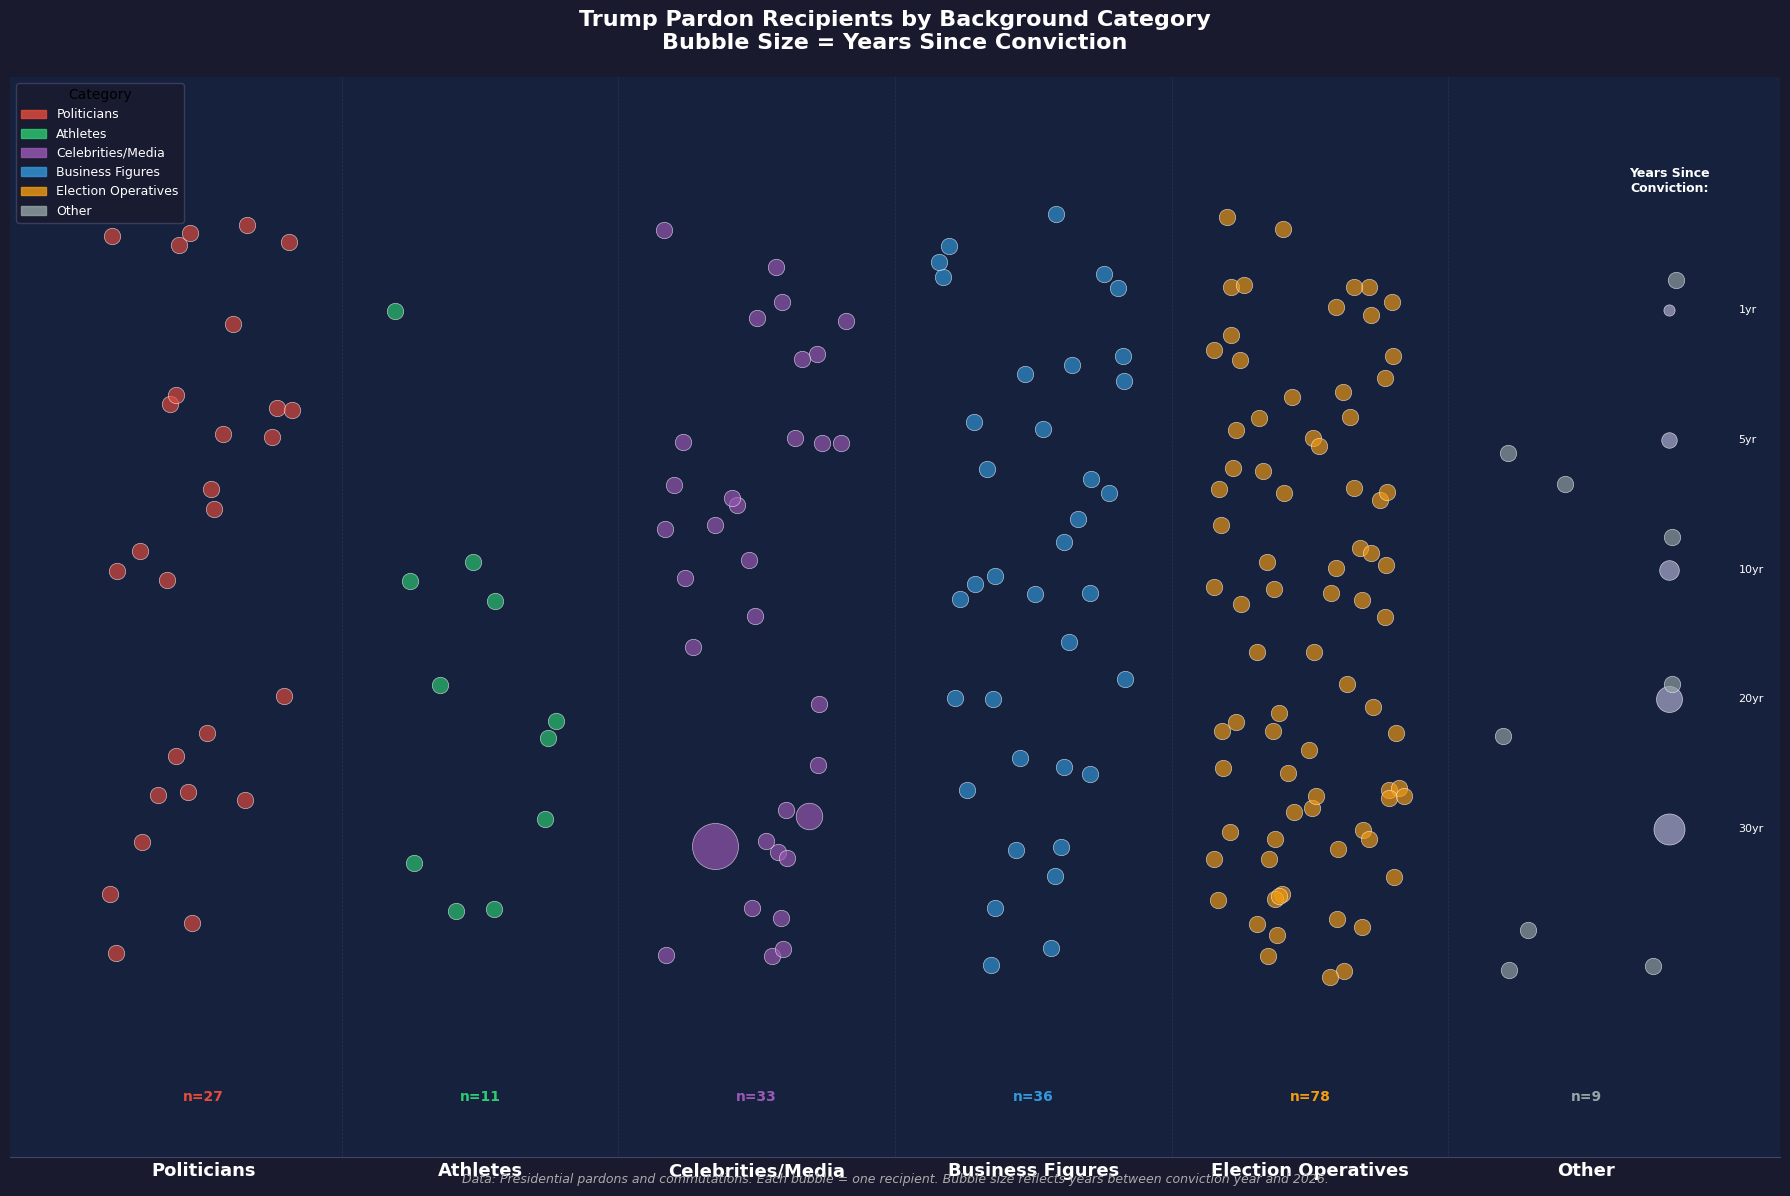

In [ ]:
# We'll keep this line commented out to avoid accidentally running generated code
# when using the "Run All" command in Jupyter. Uncomment to execute the generated code.

# exec(code)

## On-demand collaboration

We still have to clean and check our data and this chart could really use some work. Claude isn't going to replace us, or do our hard work for us.

But, it's a helpful assistant for quick iteration. In just a couple of minutes, we took a set of documents, transformed it into data, and explored some possible visualizations. We leaned into the strengths of generation while mitigating its weaknesses.

We can keep explore the data and trying out ideas until we find the strongest path towards reporting on this document set or incorporating it into a larger project. 

# Police Disciplinary File

The [Police Discipinary Files](https://www.documentcloud.org/projects/221684-police-disciplinary-files/), by our colleague Dillon Bergin, is an ongoing project to obtain files notoriously difficult to pry from law enforcement agencies. Using a different approach—requesting the files from district attorney offices, not police agencies—[a team of reporters working with MuckRock and New York Focus](https://www.muckrock.com/project/behind-the-badge-investigating-police-misconduct-1173/) has obtained over 27,000 pages of police disciplinary files in New York State and across the country.

## Extracting data from PDFs

Let's look into this document set for some records we might request within the state of Florida.

In [4]:
# Pull the police disciplinary files project
police_disciplinary_id = 221684
police_docs = documentcloud.projects.get(police_disciplinary_id)

# Enter a state to filter documents by
state = "florida"

# We can search by key/value data saved to the document
results = documentcloud.documents.search(
    f"project:{police_disciplinary_id} data_state:{state}"
)
display(results)

document_text = parallel_request(lambda doc: doc.full_text, results)
display(document_text)

<APIResults: [<Document: 25958388 - Brady Officers>, <Document: 25958387 - Law-Enforcement-Witness-Disclosure-Protocols-January-2025 1>, <Document: 25958385 - LEO Disclosure ListLEO Disclosure List>, <Document: 25958383 - Brady List Update 10 31 2024 R>]>

['Brady Report\nNORTH BAY VILLAGE 023-00220 AMY F GORDON MASTER SERGEANT\nMunicipality Court ID Name Rank\nBrady Date: 1/8/2025 Pending Investigation\nUnder Investigation\nGrand Theft\nASA(s) Johnette Hardiman\n86-24-20\nVictim(s)\nStatus:\nOPA LOCKA 008-00089 DWIGHT H WILLIAMS III POLICE OFFICER\nMunicipality Court ID Name Rank\nBrady Date: 1/7/2025 Pending\nUnder Investigation\nFelony\nASA(s) Tim VanderGiesen\n64-25-1\nVictim(s)\nStatus:\nMIAMI DADE POLICE 030-07163 DWIGHT H WILLIAMS III POLICE OFFICER\nMunicipality Court ID Name Rank\nBrady Date: 1/7/2025 Pending\nUnder Investigation\nFelony\nASA(s) Tim VanderGiesen\n64-25-1\nVictim(s)\nStatus:\nMIAMI BEACH 002-02076 JONATHAN BLANCO POLICE OFFICER\nMunicipality Court ID Name Rank\nBrady Date: 1/6/2025 Pending\nUnder Investigation\nMisd DV Battery\nASA(s) Misd DV\nM2428486\nVictim(s)\nStatus:\n1/16/2025 11:54:41 AM 1 of 20 Developed By: Christian Chiriboga\x00\n\nBrady Report\nMIAMI 001-00856 THOMAS CARROLL LIEUTENANT\nMunicipality C

Let's see if we can extract the names of some police departments from this set of documents.

In [ ]:
prompt = f"""
Find named agencies where we can file follow up public records requests related to these files. 
Return only the names of the agencies separated by commas, nothing else.
These government agencies should actually 
exist and not just be the name of a location. Expand all acronyms.

{document_text}
"""

response = claude(prompt)

agencies = [agency.strip() for agency in response.split(",")]
unique_agencies = list(set(agencies))
display(unique_agencies)

Sending prompt to Claude...


['City of Doral Police Department',
 'University of South Florida Police Department',
 'Florida Fish and Wildlife Conservation Commission',
 'Fernandina Beach Police Department',
 'Opa-locka Police Department',
 'Miami-Dade Schools Police Department',
 'North Bay Village Police Department',
 "Nassau County Sheriff's Office",
 'Florida Department of Education',
 'Florida Wildlife Conservation Commission',
 'Sweetwater Police Department',
 'Miami Police Department',
 'Florida Department of Agriculture and Consumer Services',
 'Army National Guard',
 'Temple Terrace Police Department',
 'Tampa International Airport Police Department',
 'Duval County Public Schools',
 'Miami-Dade Department of Corrections and Rehabilitation',
 'Plant City Police Department',
 'Homestead Police Department',
 'Tampa Police Department',
 'Hialeah Police Department',
 'Seminole Tribe Police Department',
 "Jacksonville Sheriff's Office",
 'United States Immigration and Customs Enforcement',
 'Miami Beach Police

## Cross-referencing against MuckRock's database

Now that we have a list of agencies, let's see how many of them exist in MuckRock's agency database. We'll need to narrow down our results to only include agencies that belong to the state we're searching in.

From this list, we'll pick an agency we want to send a request to.

In [7]:
def get_state(name):
  try:
    return muckrock.jurisdictions.list(level="s", name=name)[0]
  except:
    raise Exception(f'State not found: {name}')


def is_agency_in_state(agency, state_id):
  # If it's a state level agency, its jurisdiction will match the ID
  if agency.jurisdiction == state_id:
    return True
  # If it's a municipal agency, its jurisdiction's parent will match the ID
  jurisdiction = muckrock.jurisdictions.retrieve(agency.jurisdiction)
  if jurisdiction.parent == state_id:
    return True
  # Otherwise, it's not in the state
  return False

state_agencies = {}

def find_state_agency(name, state_id):
    results = muckrock.agencies.list(name=name)
    # Filter results to only include agencies in the specified state
    results_list = list(
        filter(lambda agency: is_agency_in_state(agency, state_id), results)
    )
    state_agencies[name] = results_list

# Find all matching Florida agencies from MuckRock's database
state = get_state('florida')
parallel_request(lambda agency: find_state_agency(agency, state.id), unique_agencies)
state_agencies = {agency: agencies for agency, agencies in state_agencies.items() if agencies}
display(state_agencies)

{'Florida Fish and Wildlife Conservation Commission': [<Agency: 19229 - Florida Fish and Wildlife Conservation Commission>],
 "Nassau County Sheriff's Office": [<Agency: 7916 - Nassau County Sheriff's Office>],
 'Miami-Dade Schools Police Department': [<Agency: 18844 - Miami-Dade Schools Police Department>],
 'Florida Department of Education': [<Agency: 6036 - Florida Department of Education>],
 'Sweetwater Police Department': [<Agency: 20110 - Sweetwater Police Department>],
 'Duval County Public Schools': [<Agency: 15151 - Duval County Public Schools>],
 'Plant City Police Department': [<Agency: 11126 - Plant City Police Department>],
 'Hialeah Police Department': [<Agency: 6596 - Hialeah Police Department>],
 'Homestead Police Department': [<Agency: 20102 - Homestead Police Department>],
 'Tampa Police Department': [<Agency: 676 - Tampa Police Department>],
 'Miami Police Department': [<Agency: 30936 - University Of Miami Police Department>,
  <Agency: 15824 - North Miami Police Dep

## Coming up with a request

From this list, let's pick the Homestead police department.

Let's peer back into the documents we were looking at to find where Homestead is mentioned in these documents. We'll use the DocumentCloud API to return us a highlight to see if it's relevant.

In [11]:
results = documentcloud.documents.search(
    "project:221684 data_state:florida Homestead", mentions=True
)
display(results[0].mentions)

[<Mention: 8 - "Brady Report
 CITY OF DORAL 097-00858 RICARDO ACEVEDO POLICE OFFICER
 Municipality Court ID Name Rank
 Brady Date: 4/9/2024 Open/Pending
 Under Investigation
 April 6, 2024 Police-Involved Shooting
 ASA(s) Philip Maniatty and Shireen Brueggeman
 SAO 
 #62/24/04/06/0
 01
 Victim(s) Jamal Wayne Wood
 Status:
 CITY OF DORAL 097-00416 ANDRE R ROMO SERGEANT
 Municipality Court ID Name Rank
 Brady Date: 4/9/2024 Open/Pending
 Under Investigation
 April 6, 2024 Police-Involved Shooting
 ASA(s) Philip Maniatty and Shireen Brueggeman
 SAO 
 #62/24/04/06/0
 01
 Victim(s) Jamal Wayne Wood
 Status:
 <em>HOMESTEAD</em> 010-00924 YADIEL RODRIGUEZ POLICE OFFICER
 Municipality Court ID Name Rank
 Brady Date: 4/3/2024 Open/Pending
 Under Investigation
 March 30, 
 2024
 Police-Involved Shooting
 ASA(s) Justin Funck and Todd Bass
 SAO # 
 62/24/03/30/00
 4
 Victim(s) Leonardo Francisco Ledea-Chong
 Status:
 <em>HOMESTEAD</em> 010-00923 BRYANT ESCALANTE POLICE OFFICER
 Municipality Court 

It looks like several Homestead Police officers appear in the Brady list document. They seem to be involved in an officer involved shooting that was  under investigation at the time this Brady list was released.

**What happened during those investigations, and what is the current status?**

Well, we can file a FOIA request to the Homestead Police Department to see what they've got on these officers!

## Sending a request

With MuckRock's API, we can create and send a public records request right from within our script.

In [ ]:
homestead_pd = state_agencies["Homestead Police Department"][0]

request_language = """
I am requesting any records relating to officers RICARDO AGUIRRE, CRYSTAL SCHNEBLY, BRYANT ESCALANTE and YADIEL RODRIGUEZ, 
including but not limited to:

- Personnel files
- Disciplinary records
- Any records referencing the officers and their connection with officer credibility disclosure lists

If there are any fees associated with this request, please notify me in advance.
"""

request_to_send = {
  "title": "Homestead PD disciplinary records",
  "requested_docs": request_language,
  "agencies": [homestead_pd.id]
}

In order to submit this request, we need to be signed in to our MuckRock account and retrieve our organization's ID.

We can save our `MUCKROCK_USERNAME` and `MUCKROCK_PASSWORD` to a local `.env` file.

In [ ]:
from dotenv import load_dotenv
from muckrock import MuckRock

load_dotenv()

authenticated_muckrock = MuckRock(
   username=os.environ["MUCKROCK_USERNAME"],
   password=os.environ["MUCKROCK_PASSWORD"]
)

def list_my_organizations():
  me = authenticated_muckrock.users.me()
  display(me)
  my_orgs = []
  for org in me.organizations:
      org_data = authenticated_muckrock.organizations.retrieve(org)
      my_orgs.append((org_data.name, org_data.id))
  display(my_orgs)

list_my_organizations()

Finally, we'll add our organization ID to the request and send it!

In [ ]:
request_to_send["organization"] = 1 # Replace with your organization ID

# Uncommenting this line and running the code will create a new request in MuckRock, so be cautious!
# new_request = authenticated_muckrock.requests.create(**request_to_send) 

## Conducting large-scale public records work with MuckRock's API

As you might imagine, we could abstract this process so that we're sending out large batches of requests to all the the departments about all the officers with pending investigations as of 2024. Automating this kind of tedious reporting practice is what data journalists excel at!

# IG Reports

Finally, let's at a project by Chris Keller, a data & graphics reporter at The Associated Press. Chris created an archive of reports from the [Office of Inspector General](https://www.documentcloud.org/projects/221213-archive-of-inspector-general-reports/).

In this project, we can see a lot of FOIA logs—these tells us what other people have filed a request for in the past. Let's get Claude to take a look at a few of these and build a table of FOIA ideas for us to look at.

In [ ]:
# Fetch the project
ig_reports = documentcloud.projects.get(221213)

# Search documents for FOIA 
foia_logs = documentcloud.documents.search(f"project:{ig_reports.id} title:log*")
display(foia_logs)

<APIResults: [<Document: 25888163 - sites-default-files-assets-oig-foia-log-3rd13>, <Document: 25887614 - sites-default-files-assets-oig-foia-log-3qtr09>, <Document: 25888674 - sites-default-files-assets-oig-foia-log-2qtr11>, <Document: 25888054 - sites-default-files-assets-oig-foia-log-2rd12>, <Document: 25887999 - sites-default-files-assets-oig-foia-log-2rd13>, <Document: 25888729 - sites-default-files-assets-oig-foia-log-3qtr10>, <Document: 25888439 - sites-default-files-assets-oig-foia-log-1qtr09>, <Document: 25887691 - sites-default-files-assets-oig-foia-log-1st11>, <Document: 25888200 - sites-default-files-assets-oig-foia-log-3rd12>, <Document: 25888031 - sites-default-files-assets-oig-foia-log-1qtr10>, <Document: 25887743 - sites-default-files-assets-oig-foia-log-1st14>, <Document: 25887615 - sites-default-files-assets-oig-foia-log-2qtr09>, <Document: 25887595 - sites-default-files-assets-oig-foia-log-1st13>, <Document: 25888727 - sites-default-files-assets-oig-foia-log-2qtr10>,

47

# Working directly with PDFs and Claude

Now, we're going to create a new helper that sends PDFs from DocumentCloud right to Claude, relying on its [built-in PDF support](https://platform.claude.com/docs/en/build-with-claude/pdf-support).

We also need to use Claude's streaming responses, since this will take a while to process.

There's one catch, though: Claude can't access S3 where we host these files, so we need to send the actual PDFs through to Claude as base64 encoded data.

In [ ]:
def claude_with_pdf(prompt, pdf_files, system="You are a PDF analysis assistant for data journalism tasks."):
    import base64
    try:
      print("Sending prompt to Claude with PDF capabilities...")
      with anthropic.messages.stream(
          model="claude-sonnet-4-6",
          max_tokens=2000,
          temperature=0,
          system=system,
          messages=[
              {
                "role": "user",
                "content": [{
                    "type": "document",
                    "source": {
                        "type": "base64",
                        "media_type": "application/pdf",
                        "data": base64.standard_b64encode(pdf).decode("utf-8")
                    }
                } for pdf in pdf_files]
              },
              {"role": "user", "content": prompt}
          ]
      ) as stream:
        message = stream.get_final_message()
        return message.content[0].text
    except Exception as e:
      return f"An error occurred: {e}"


prompt = """
Extract all tables from the attached documents.

Output STRICT CSV where:

- Every field must be wrapped in double quotes ""
- Separate fields only with commas
- If a field contains double quotes, escape them by doubling them ("")
- Preserve multi-line log messages inside the quotes if they exist
- Do not output markdown, explanations, or code fences
- Output CSV text only

Return nothing except CSV content.
"""

# Get the PDF files for the FOIA logs
print('Getting PDFs from DocumentCloud...')
pdf_files = parallel_request(lambda doc: doc.pdf, foia_logs)
response = claude_with_pdf(prompt, pdf_files[:2]) # Limiting to 2 PDFs for testing purposes
display(response)

# Save the CSV Claude returned
save_csv(response, 'ig_report_foia_logs.csv')
foia_log_df = load_csv_to_dataframe('ig_report_foia_logs.csv')




Getting PDFs from DocumentCloud...
Sending prompt to Claude with PDF capabilities...


'"Fiscal Year","Case Number","Recv\'d in FOIA","Document Requested","Disposition","Denial Reason"\n"2013","115","07/02/2013","Self requester","Other Reason for Nondisclosure","No records"\n"2013","116","07/09/2013","Self requester","Partial Grant",""\n"2013","117","07/09/2013","A database of all employees who used ""official time"" under 5 USC 7131 or related statutes since January 1, 2009; and copies of current master labor agreements governing the use of official time by top union officials","Other Reason for Nondisclosure","No records"\n"2013","118","07/10/2013","All records pertaining to the death of an ICE detainee","Partial Grant",""\n"2013","119","07/11/2013","Self requester","Total Denial",""\n"2013","120","07/12/2013","Self requester","Partial Grant",""\n"2013","121","07/16/2013","Self requester","Total Denial",""\n"2013","122","07/18/2013","Records pertaining to third parties","Total Denial","Specify other"\n"2013","123","07/22/2013","Annual performance data for program line 

CSV content saved to output/{filename}


,ig_report_foia_logs.csv
